# 📚 Author

### **Eli Oun**  
💻 *Spotify ML*


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [ ]:
data_path = '/content/spotify_songs_train.csv'
data = pd.read_csv(data_path)

In [ ]:
data.dropna(inplace=True)  # Drop rows with missing values



*   Drop Irrelevant Columns: These columns (like names and IDs) do not directly influence the prediction target and could add noise to the model.
*   Retain Only Numeric Columns: While converting non-numeric columns to numerical formats (e.g., using one-hot encoding or label encoding) is a valid approach, I focused on numeric features to explore feature engineering and derive meaningful interactions form it while working on this project



In [ ]:
# Feature Selection - Remove Irrelevant Columns
irrelevant_columns = ['Unnamed: 0', 'track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id']
data.drop(columns=irrelevant_columns, inplace=True)

In [ ]:
# Ensure All Features are Numeric
data = data.select_dtypes(include=[np.number])

In [ ]:
important_features = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'instrumentalness', 'duration_ms']

* Create Interaction Terms: These derived features capture relationships between existing variables (e.g., how danceability interacts with energy).
* Transform Features: Non-linear transformations (like squaring tempo) help models identify complex patterns.
* This can enhances the dataset by adding new predictive variables, potentially improving the model's performance by capturing additional variance.

In [ ]:
# Feature Engineering
# Interaction Terms
data['danceability_energy'] = data['danceability'] * data['energy']
data['instrumentalness_duration'] = data['instrumentalness'] * data['duration_ms']
data['tempo_squared'] = data['tempo'] ** 2
important_features.extend(['danceability_energy', 'instrumentalness_duration', 'tempo_squared'])

* Correlation Matrix: Quantifies the strength and direction of relationships between features and the target.
* Sort by Importance: Identifies features most strongly correlated with the target (track_popularity).

Prioritizing features with high correlation helps focus the model on inputs with more predictive power.

In [ ]:
# Data Review and Analysis
correlation_matrix = data.corr()
popularity_correlation = correlation_matrix['track_popularity'].sort_values(ascending=False)

In [ ]:
# Summarized Table of Feature Importance
feature_importance_table = pd.DataFrame({
    'Feature Name': popularity_correlation.index,
    'Correlation Score': popularity_correlation.values
}).reset_index(drop=True)

In [ ]:
print("\n--- Feature Importance Table ---")
print(feature_importance_table)


--- Feature Importance Table ---
                 Feature Name  Correlation Score
0            track_popularity           1.000000
1                acousticness           0.084184
2                danceability           0.067542
3                    loudness           0.052780
4                     valence           0.034521
5                        mode           0.009998
6                 speechiness           0.006649
7                         key           0.002933
8               tempo_squared           0.002873
9                       tempo          -0.003550
10        danceability_energy          -0.043963
11                   liveness          -0.056848
12                     energy          -0.113533
13                duration_ms          -0.143918
14           instrumentalness          -0.152489
15  instrumentalness_duration          -0.167967


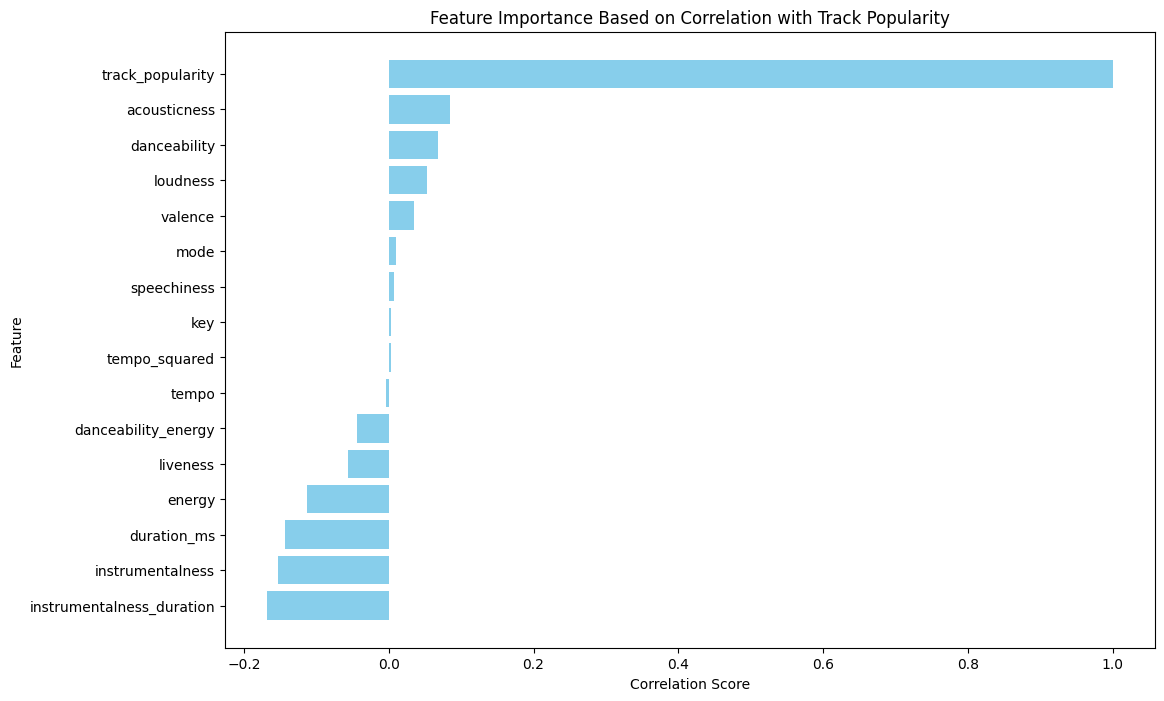

In [ ]:
# Visualization of Feature Correlations
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_table['Feature Name'], feature_importance_table['Correlation Score'], color='skyblue')
plt.xlabel('Correlation Score')
plt.ylabel('Feature')
plt.title('Feature Importance Based on Correlation with Track Popularity')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Prepare Features and Target
data = data[important_features + ['track_popularity']]

In [ ]:
# Feature Scaling
scaler = RobustScaler()
scaled_features = scaler.fit_transform(data[important_features])

In [ ]:
# Split the Dataset
X = scaled_features
y = data['track_popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)

In [ ]:
# Random Forest Regressor with Exhaustive Hyperparameter Tuning
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=25),
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_log_error',
    n_jobs=-1
)

In [ ]:
grid_search_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=25), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_log_error')

In [ ]:
# Best Random Forest Model Evaluation
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
msle_rf = mean_squared_log_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [ ]:
print("Best Parameters for Random Forest:", grid_search_rf.best_params_)
print(f"Random Forest MSLE: {msle_rf:.4f}")
print(f"Random Forest R-squared: {r2_rf:.4f}")

Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest MSLE: 1.5649
Random Forest R-squared: 0.2552


# Testing

In [ ]:
test_data_path = '/content/spotify_songs_X_test.csv'
test_data = pd.read_csv(test_data_path)


In [ ]:
test_data.dropna(inplace=True)

In [ ]:
test_data.drop(columns=irrelevant_columns, inplace=True)

In [ ]:
test_data = test_data.select_dtypes(include=[np.number])

In [ ]:
test_data['danceability_energy'] = test_data['danceability'] * test_data['energy']
test_data['instrumentalness_duration'] = test_data['instrumentalness'] * test_data['duration_ms']
test_data['tempo_squared'] = test_data['tempo'] ** 2

In [ ]:
test_features = test_data[important_features]
scaled_test_features = scaler.transform(test_features)

In [ ]:

test_predictions = best_rf.predict(scaled_test_features)
output = pd.DataFrame({'Unnamed: 0': test_data.index, 'ML prediction': test_predictions})
output.to_csv('/content/output.csv', index=False)

# Recommender System Based on Item Similarity

In [ ]:
# Calculate cosine similarity between tracks
similarity_matrix = cosine_similarity(scaled_features)

* Cosine Similarity: Measures the similarity between tracks based on feature vectors.

Personalizes the user experience by leveraging feature similarity, demonstrating a practical application of the dataset.

In [ ]:
# Function to get top 5 track recommendations for a user based on liked tracks
def get_recommendations(liked_track_indices, num_recommendations=5):
    # Calculate the average similarity of all liked tracks
    avg_similarity = np.mean(similarity_matrix[liked_track_indices], axis=0)

    # Get the indices of the most similar tracks, excluding the liked tracks
    similar_tracks_indices = np.argsort(avg_similarity)[::-1]
    similar_tracks_indices = [i for i in similar_tracks_indices if i not in liked_track_indices]

    return similar_tracks_indices[:num_recommendations]

In [ ]:
liked_track_indices = [0, 5, 2, 3, 4]  # Indices of tracks the user likes
recommended_track_indices = get_recommendations(liked_track_indices)
print("Recommended Track Indices:", recommended_track_indices)
print("Recommended Tracks:", data.iloc[recommended_track_indices])

Recommended Track Indices: [9904, 5943, 6584, 2695, 2102]
Recommended Tracks:       danceability  energy  loudness  valence    tempo  instrumentalness  \
9905         0.622   0.961    -2.616    0.687  149.962          0.000160   
5944         0.604   0.949    -3.577    0.664  144.864          0.000427   
6585         0.691   0.853    -2.528    0.762  145.999          0.000071   
2695         0.648   0.931    -3.150    0.744  153.649          0.000000   
2102         0.630   0.888    -2.388    0.561  141.019          0.000002   

      duration_ms  danceability_energy  instrumentalness_duration  \
9905       211573             0.597742                  33.851680   
5944       222726             0.573196                  95.104002   
6585       215867             0.589423                  15.391317   
2695       213067             0.603288                   0.000000   
2102       233333             0.559440                   0.452666   

      tempo_squared  track_popularity  
9905   224

## Why This Approach

### 1. Simplicity and Efficiency
- **Cosine Similarity** is computationally efficient and effective for determining the similarity between items (tracks in this case). It measures the angle between two vectors, ensuring that similarity is based on the direction rather than magnitude, which is important for normalized features.
- Since the system only uses the similarity matrix, it avoids the complexities of training a predictive model, making it simpler to implement and faster to compute.

---

### 2. Personalized Recommendations
- The system generates recommendations by calculating the **average similarity** of the user’s liked tracks. This personalization ensures that the recommended tracks are closely aligned with the user’s preferences.
- By excluding the indices of already liked tracks, the approach avoids **redundant recommendations**.

---

### 3. Domain Independence
- The method only relies on **item features** and their similarity, so it is **domain-independent**. Whether the items are songs, movies, or products, as long as their features are represented numerically, this method is applicable.

---

### 4. Interpretability
- The **similarity matrix** and the ranking mechanism make the recommendations **explainable**. For example, you can explicitly point out which features made a track similar to the user's liked tracks.


# Papers and GitHub Repositories

## Papers

### Random Forest and Feature Importance
- **Breiman, L.** (2001). *"Random Forests."* Machine Learning, 45(1), 5–32. [DOI:10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324)

### Feature Engineering
- **Kuhn, M., & Johnson, K.** (2019). *Feature Engineering and Selection: A Practical Approach for Predictive Models.* CRC Press.

---

## GitHub Repositories

### Feature Engineering
- [Feature-engine GitHub](https://github.com/feature-engine/feature_engine)

### Random Forest Implementation
- [Scikit-learn Random Forest Examples](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

### Recommender Systems
- [Implicit Recommender GitHub](https://github.com/benfred/implicit)

### Cosine Similarity and Recommendations
- [Cosine Similarity Examples](https://github.com/topics/cosine-similarity)
